# RFM Customer Segmentation
### Data Collection, Cleaning & Exploratory Data Analysis

**Dataset:** Online Retail II (UCI Machine Learning Repository)
**Source:** https://archive.ics.uci.edu/dataset/502/online+retail+ii
**Period:** 01/12/2009 – 09/12/2011
**Author:** Pratham Kumar

---
**Pipeline stage:** Python → SQL → Excel → Tableau Public
This notebook covers the **Python** stage only: load the raw data, clean it, explore it,
and build the customer-level RFM base table that the SQL phase will score and segment.

**Outputs produced by this notebook:**
- `online_retail_clean.csv` — cleaned, transaction-level data
- `rfm_base_table.csv` — one row per customer with Recency, Frequency, Monetary values

## 1. Setup and Imports

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Data Collection

The file `online_retail_II.xlsx` contains **two sheets** — one per year. Both need to be
loaded and stacked into a single DataFrame.

In [116]:
FILE_PATH = "/Users/prathamkumar/online_retail_II.xlsx" 

df_2009_2010 = pd.read_excel(FILE_PATH, sheet_name="Year 2009-2010")
df_2010_2011 = pd.read_excel(FILE_PATH, sheet_name="Year 2010-2011")

df = pd.concat([df_2009_2010, df_2010_2011], ignore_index=True)

print(f"2009-2010 sheet: {df_2009_2010.shape}")
print(f"2010-2011 sheet: {df_2010_2011.shape}")
print(f"Combined:        {df.shape}")

df.head()

2009-2010 sheet: (525461, 8)
2010-2011 sheet: (541910, 8)
Combined:        (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


## 3. Initial Exploration

dtypes, missing values, and the known problem patterns for this dataset
(cancellations, adjustments, non-product stock codes).

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [118]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Invoice,"1,067,371.00","53,628.00","537,434.00","1,350.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,1067371,5305,85123A,5829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,1062989,5698,WHITE HANGING HEART T-LIGHT HOLDER,5918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,"1,067,371.00",NaN,NaN,NaN,9.94,"-80,995.00",1.00,3.00,10.00,"80,995.00",172.71
InvoiceDate,1067371,NaN,NaN,NaN,2011-01-02 21:13:55.394028544,2009-12-01 07:45:00,2010-07-09 09:46:00,2010-12-07 15:28:00,2011-07-22 10:23:00,2011-12-09 12:50:00,NaN
Price,"1,067,371.00",NaN,NaN,NaN,4.65,"-53,594.36",1.25,2.10,4.15,"38,970.00",123.55
Customer ID,"824,364.00",NaN,NaN,NaN,"15,324.64","12,346.00","13,975.00","15,255.00","16,797.00","18,287.00","1,697.46"
Country,1067371,43,United Kingdom,981330,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [119]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
Invoice,0,0.00
StockCode,0,0.00
Description,4382,0.41
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Customer ID,243007,22.77
Country,0,0.00


In [120]:
# Cancellations: Invoice starts with 'C'
cancelled = df["Invoice"].astype(str).str.startswith("C")
print(f"Cancellation rows: {cancelled.sum():,} ({cancelled.mean()*100:.2f}%)")

# Adjustments / bad debt entries: Invoice starts with 'A'
adjustments = df["Invoice"].astype(str).str.startswith("A")
print(f"Adjustment rows:   {adjustments.sum():,} ({adjustments.mean()*100:.2f}%)")

Cancellation rows: 19,494 (1.83%)
Adjustment rows:   6 (0.00%)


In [121]:
# Non-numeric / non-standard StockCodes worth inspecting (postage, discounts, manual entries, etc.)
non_numeric_codes = df.loc[~df["StockCode"].astype(str).str.replace("[a-zA-Z]", "", regex=True).str[:5].str.isdigit(), "StockCode"]
non_numeric_codes.value_counts().head(20)

StockCode
POST            2122
DOT             1446
M               1421
D                177
S                104
BANK CHARGES     102
ADJUST            67
AMAZONFEE         43
gift_0001_20      29
gift_0001_30      29
DCGSSGIRL         25
DCGSSBOY          23
PADS              19
CRUK              16
gift_0001_10      16
gift_0001_50       8
gift_0001_40       7
B                  6
m                  5
gift_0001_80       4
Name: count, dtype: int64

In [122]:
# The exclusion list correctly catches the dominant junk codes (POST postage, DOT postage variant, M manual entries, BANK CHARGES, AMAZONFEE).
# A few low-volume codes (gift_0001_XX, DCGSSGIRL/BOY) were reviewed and kept as legitimate product SKUs rather than excluded,
# since their descriptions confirm they represent real gift-set products, not administrative entries.

## 4. Data Cleaning

In [123]:
cleaning_log = {"0_starting_rows": len(df)}
df_clean = df.copy()

### 4.1 Drop rows with missing Customer ID

RFM is customer-level analysis — a transaction with no customer attached is unusable and
cannot be recovered, so these rows are dropped rather than imputed.

In [124]:
df_clean = df_clean.dropna(subset=["Customer ID"])
cleaning_log["1_after_dropna_customerid"] = len(df_clean)
print(f"Rows remaining: {len(df_clean):,}")

Rows remaining: 824,364


### 4.2 Remove cancelled orders

`Invoice` values starting with `C` are cancellations (negative `Quantity`). For RFM we
want realized purchase behavior, so these are removed rather than netted against the
original order.

In [125]:
df_clean = df_clean[~df_clean["Invoice"].astype(str).str.startswith("C")]
cleaning_log["2_after_remove_cancellations"] = len(df_clean)
print(f"Rows remaining: {len(df_clean):,}")

Rows remaining: 805,620


### 4.3 Remove adjustment / bad-debt entries

`Invoice` values starting with `A` are manual bad-debt adjustments, not real customer
transactions.

In [126]:
df_clean = df_clean[~df_clean["Invoice"].astype(str).str.startswith("A")]
cleaning_log["3_after_remove_adjustments"] = len(df_clean)
print(f"Rows remaining: {len(df_clean):,}")

Rows remaining: 805,620


### 4.4 Remove non-product stock codes

Codes like postage, discounts, manual entries, and bank charges aren't real products and
would distort revenue if left in. Inspect `non_numeric_codes` from Section 3.

In [127]:
non_product_codes = ["POST", "D", "M", "DOT", "BANK CHARGES", "TEST001", "TEST002", "AMAZONFEE", "CRUK", "ADJUST", "PADS", "S"]
df_clean = df_clean[~df_clean["StockCode"].astype(str).str.upper().isin(non_product_codes)]
cleaning_log["4_after_remove_nonproduct_codes"] = len(df_clean)
print(f"Rows remaining: {len(df_clean):,}")

Rows remaining: 802,951


### 4.5 Remove non-positive Quantity or Price

Zero/negative quantity or price rows are the remaining refunds, samples, or data-entry
errors not already caught above.

In [128]:
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["Price"] > 0)]
cleaning_log["5_after_remove_nonpositive_qty_price"] = len(df_clean)
print(f"Rows remaining: {len(df_clean):,}")

Rows remaining: 802,890


### 4.6 Drop exact duplicate rows

In [129]:
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
cleaning_log["6_after_drop_duplicates"] = len(df_clean)
print(f"Duplicates removed: {before - len(df_clean):,}")
print(f"Rows remaining: {len(df_clean):,}")

Duplicates removed: 26,060
Rows remaining: 776,830


### 4.7 Fix dtypes & add Revenue column

In [130]:
df_clean["Customer ID"] = df_clean["Customer ID"].astype(int)
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["Price"]

cleaning_log["7_final_rows"] = len(df_clean)
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00


### 4.8 Cleaning summary

In [131]:
log_df = pd.DataFrame(list(cleaning_log.items()), columns=["step", "rows_remaining"])
log_df["rows_dropped"] = log_df["rows_remaining"].diff().fillna(0).abs().astype(int)
log_df

,step,rows_remaining,rows_dropped
0,0_starting_rows,1067371,0
1,1_after_dropna_customerid,824364,243007
2,2_after_remove_cancellations,805620,18744
3,3_after_remove_adjustments,805620,0
4,4_after_remove_nonproduct_codes,802951,2669
5,5_after_remove_nonpositive_qty_price,802890,61
6,6_after_drop_duplicates,776830,26060
7,7_final_rows,776830,0


In [132]:
# Missing Customer ID was the dominant cleaning driver (243,007 rows, 22.8%), followed by exact duplicate rows (26,060, ~3.2%). 
# Adjustment-invoice removal dropped 0 additional rows since those entries had no customer attribution and were already excluded upstream
# — confirming bad-debt adjustments aren't tied to real customer accounts in this data.
# Final retained dataset: 776,830 clean transaction rows (72.8% of raw).

## 5. Post-Cleaning Validation

In [133]:
print("Rows:              ", f"{len(df_clean):,}")
print("Unique customers:  ", f"{df_clean['Customer ID'].nunique():,}")
print("Unique invoices:   ", f"{df_clean['Invoice'].nunique():,}")
print("Unique products:   ", f"{df_clean['StockCode'].nunique():,}")
print("Countries:         ", df_clean["Country"].nunique())
print("Date range:        ", df_clean["InvoiceDate"].min(), "to", df_clean["InvoiceDate"].max())
print("Negative revenue rows:", (df_clean["Revenue"] < 0).sum())
print("Total revenue:     ", f"£{df_clean['Revenue'].sum():,.2f}")

Rows:               776,830
Unique customers:   5,853
Unique invoices:    36,603
Unique products:    4,622
Countries:          41
Date range:         2009-12-01 07:45:00 to 2011-12-09 12:50:00
Negative revenue rows: 0
Total revenue:      £17,081,859.77


In [134]:
df_clean.describe()[["Quantity", "Price", "Revenue"]]

,Quantity,Price,Revenue
count,"776,830.00","776,830.00","776,830.00"
mean,13.52,2.95,21.99
min,1.00,0.03,0.06
25%,2.00,1.25,4.95
50%,6.00,1.95,12.48
75%,12.00,3.75,19.80
max,"80,995.00",649.50,"168,469.60"
std,146.07,4.41,225.90


In [135]:
# Cleaned dataset: 776,830 rows, 5,853 unique customers, 36,603 invoices, 4,622 products, 41 countries, £17.08M total revenue. 
# Zero negative-revenue rows confirms the cleaning filters worked correctly. 
# Quantity and Revenue show extreme right-skew (max single-line quantity of 80,995 units, revenue std of £225.90 vs. a £21.99 mean) 
# — consistent with the dataset's mix of wholesale and retail buyers, and expected to carry through into the Monetary dimension of RFM.

## 6. Save Clean Dataset

In [136]:
df_clean.to_csv("online_retail_clean.csv", index=False)
print("Saved: online_retail_clean.csv")

Saved: online_retail_clean.csv


In [137]:
sample = df_clean.sample(n=2000, random_state=42)
sample = sample.sort_values("InvoiceDate")  # optional, makes it read nicer chronologically
sample.to_csv("data_clean_sample.csv", index=False)

print(sample.shape)
print(sample.columns.tolist())

(2000, 9)
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue']


## 7. Exploratory Data Analysis

Goal here isn't the final findings — those come once RFM segments exist — just enough
context to sanity-check the data and spot anything that should inform the RFM design
(e.g. how skewed spending is, whether the UK dominates so heavily that country-level
cuts of RFM are worth doing separately).

### 7.1 Revenue overview

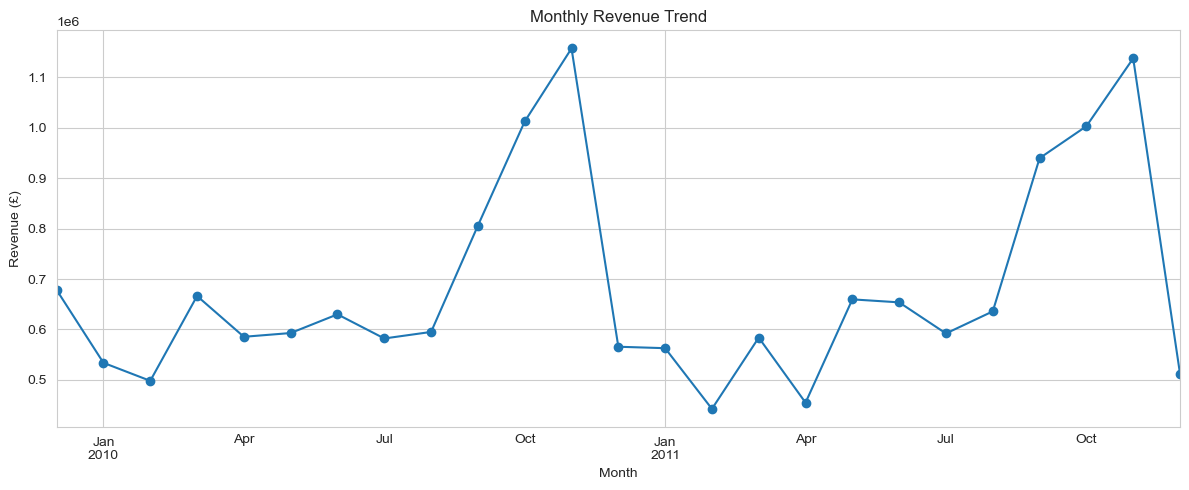

In [138]:
monthly_revenue = df_clean.set_index("InvoiceDate").resample("ME")["Revenue"].sum()

monthly_revenue.plot(kind="line", marker="o", figsize=(12, 5), title="Monthly Revenue Trend")
plt.ylabel("Revenue (£)")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

### 7.2 Revenue by country (top 10)

Expect the UK to dominate heavily since this is a UK-based retailer — worth checking how lopsided it actually is.

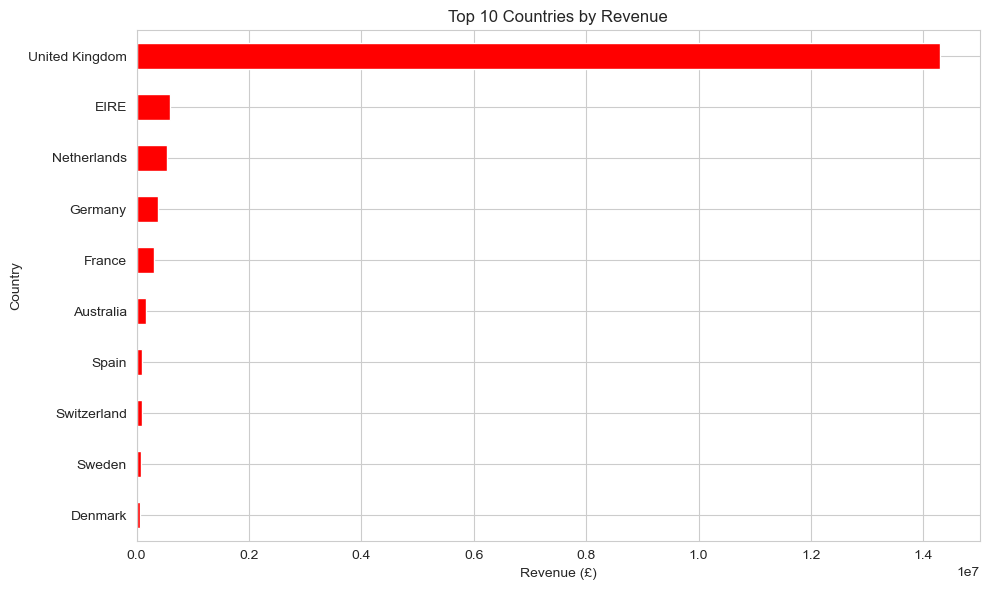

UK share of total revenue: 83.7%


In [139]:
country_revenue = df_clean.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

country_revenue.plot(kind="barh", figsize=(10, 6), title="Top 10 Countries by Revenue", color = 'r')
plt.xlabel("Revenue (£)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

uk_share = df_clean[df_clean["Country"] == "United Kingdom"]["Revenue"].sum() / df_clean["Revenue"].sum()
print(f"UK share of total revenue: {uk_share*100:.1f}%")

### 7.3 Top products

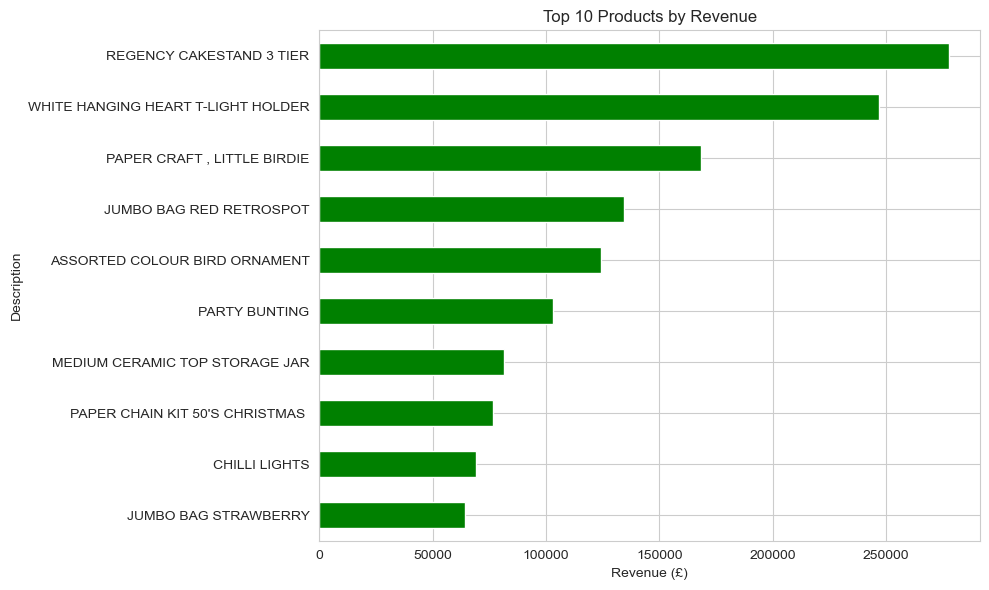

In [140]:
top_products = (
    df_clean.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.plot(kind="barh", figsize=(10, 6), title="Top 10 Products by Revenue", color = 'g')
plt.xlabel("Revenue (£)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 7.4 Orders per customer

This distribution is the raw material for the Frequency dimension of RFM — expect it to be heavily right-skewed (most customers order rarely, a few order constantly).

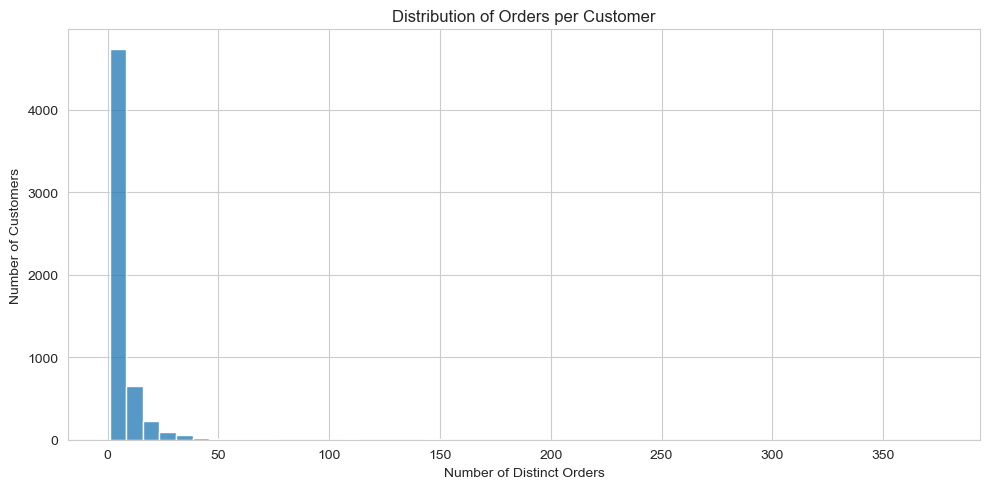

count   5,853.00
mean        6.25
std        12.76
min         1.00
25%         1.00
50%         3.00
75%         7.00
max       375.00
Name: Invoice, dtype: float64


In [141]:
orders_per_customer = df_clean.groupby("Customer ID")["Invoice"].nunique()

plt.figure(figsize=(10, 5))
sns.histplot(orders_per_customer, bins=50)
plt.title("Distribution of Orders per Customer")
plt.xlabel("Number of Distinct Orders")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

print(orders_per_customer.describe())

### 7.5 Revenue concentration (Pareto check)

A quick check of what share of revenue comes from the top 20% of customers — this is the
pattern RFM exists to help a business act on, so it's worth confirming it shows up here.

Top 20% of customers (1,170 customers) generate 77.2% of revenue


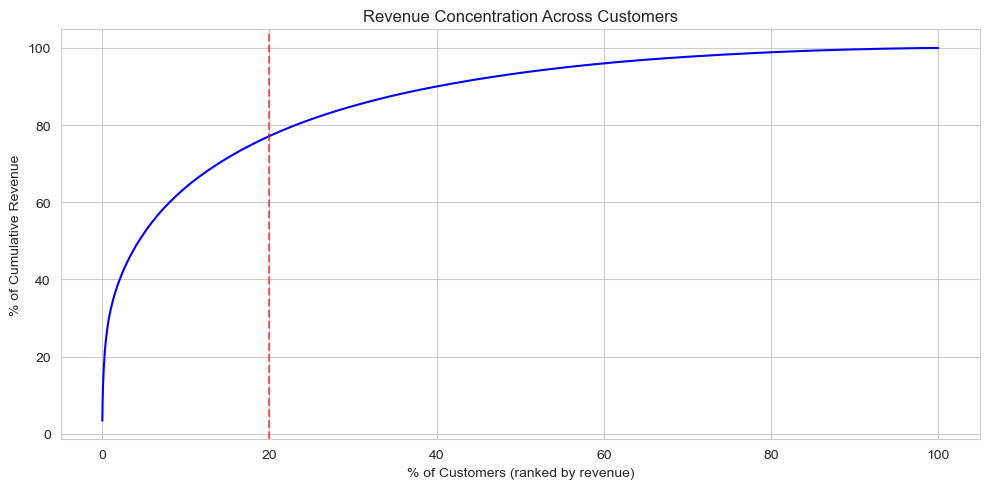

In [142]:
customer_revenue = df_clean.groupby("Customer ID")["Revenue"].sum().sort_values(ascending=False)
cum_share = customer_revenue.cumsum() / customer_revenue.sum()

top_20pct_cutoff = int(len(customer_revenue) * 0.2)
top_20pct_revenue_share = cum_share.iloc[top_20pct_cutoff]

print(f"Top 20% of customers ({top_20pct_cutoff:,} customers) generate {top_20pct_revenue_share*100:.1f}% of revenue")

plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(cum_share) + 1) / len(cum_share) * 100, cum_share.values * 100, color = 'blue')
plt.axvline(20, color="red", linestyle="--", alpha=0.6)
plt.xlabel("% of Customers (ranked by revenue)")
plt.ylabel("% of Cumulative Revenue")
plt.title("Revenue Concentration Across Customers")
plt.tight_layout()
plt.show()

In [143]:
# Revenue is heavily concentrated: the top 20% of customers (1,170) generate 77.2% of total revenue — a near-textbook Pareto distribution. 
# This confirms the core business case for RFM segmentation 
# — a small, identifiable customer group drives the large majority of value,
# and protecting/retaining that group should be the primary action-oriented output of the segmentation.

## 8. Building the RFM Base Table

This is the key output of the Python phase: one row per customer with raw Recency,
Frequency, and Monetary values. **Scoring (quintiles) and segmentation happen in the SQL** — this notebook only produces the raw metrics.

**Snapshot date** = the day after the last transaction in the dataset. Using "today's"
date would make every customer look inactive since the data ends in 2011.

In [144]:
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date}")

Snapshot date: 2011-12-10 12:50:00


In [145]:
rfm = df_clean.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum"),
).reset_index()

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346,326,3,"77,352.96"
1,12347,2,8,"4,921.53"
2,12348,75,5,"1,658.40"
3,12349,19,3,"3,678.69"
4,12350,310,1,294.40


In [146]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,"5,853.00","5,853.00","5,853.00","5,853.00"
mean,"15,319.27",200.25,6.25,"2,918.48"
std,"1,715.12",208.53,12.76,"14,335.33"
min,"12,346.00",1.00,1.00,2.95
25%,"13,837.00",25.00,1.00,340.85
50%,"15,320.00",95.00,3.00,856.03
75%,"16,802.00",379.00,7.00,"2,240.90"
max,"18,287.00",739.00,375.00,"580,987.04"


### 8.1 RFM distributions

Recency should look roughly uniform-ish across the window; Frequency and Monetary are typically heavily right-skewed — a handful of power customers pull the mean well above the median, which is exactly the pattern RFM segmentation is designed to surface.

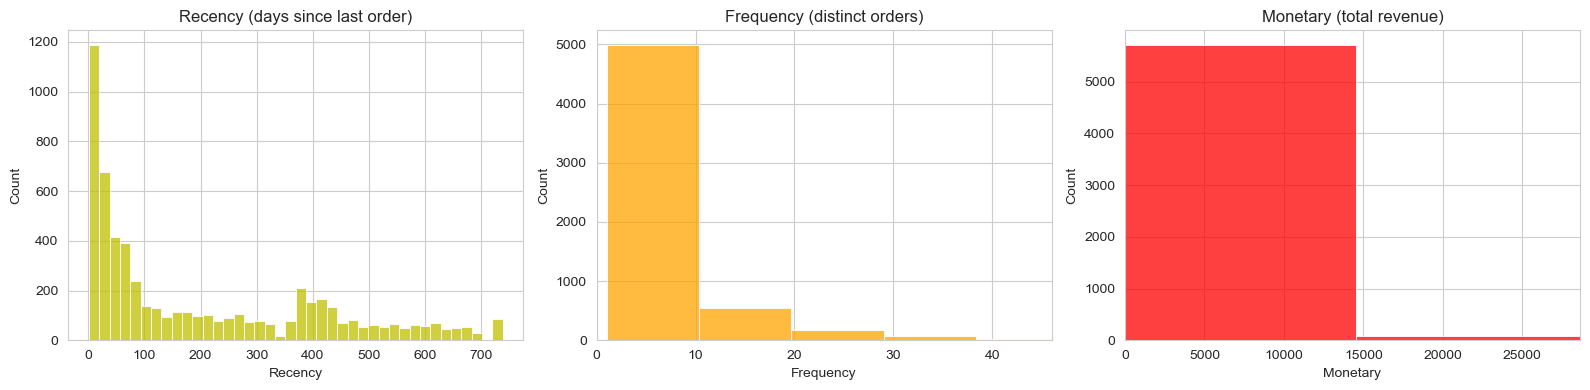

In [147]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(rfm["Recency"], bins=40, ax=axes[0], color = 'y')
axes[0].set_title("Recency (days since last order)")

sns.histplot(rfm["Frequency"], bins=40, ax=axes[1], color = 'orange')
axes[1].set_title("Frequency (distinct orders)")
axes[1].set_xlim(0, rfm["Frequency"].quantile(0.99))

sns.histplot(rfm["Monetary"], bins=40, ax=axes[2], color = 'r')
axes[2].set_title("Monetary (total revenue)")
axes[2].set_xlim(0, rfm["Monetary"].quantile(0.99))

plt.tight_layout()
plt.show()

### 8.2 Sanity check

A few things worth checking before handing this off to SQL:
- `Recency` should range from 0 to roughly the length of the dataset's date window.
- `Frequency` minimum should be 1 (every customer in this table has at least one clean order).
- `Monetary` should have no zero or negative values, given the cleaning applied earlier.

In [148]:
print("Recency range:  ", rfm["Recency"].min(), "-", rfm["Recency"].max())
print("Frequency range:", rfm["Frequency"].min(), "-", rfm["Frequency"].max())
print("Monetary range: ", f"£{rfm['Monetary'].min():,.2f}", "-", f"£{rfm['Monetary'].max():,.2f}")
print("Total customers:", len(rfm))

Recency range:   1 - 739
Frequency range: 1 - 375
Monetary range:  £2.95 - £580,987.04
Total customers: 5853


In [149]:
# All sanity checks pass. Recency range (1–739 days) matches the dataset's ~2-year window exactly. 
# Frequency minimum of 1 and all-positive Monetary values confirm the cleaning pipeline left no invalid customers in the base table. 
#The wide spread on both Frequency (1–375) and Monetary (£2.95–£580,987) mirrors the right-skew
# and revenue concentration already seen in Sections 5 and 7.5 — the RFM base table is ready for quintile scoring.

## 9. Saving RFM Base Table

In [150]:
rfm.to_csv("rfm_base_table.csv", index=False)
print("Saved: rfm_base_table.csv")
print(f"Shape: {rfm.shape}")

Saved: rfm_base_table.csv
Shape: (5853, 4)


## 10. Summary

**Outputs:**
- `online_retail_clean.csv` — cleaned transaction-level data, ready for SQL
- `rfm_base_table.csv` — one row per customer: `Customer ID`, `Recency`, `Frequency`, `Monetary`

**Final dataset stats:**
- Rows retained: 776,830 of 1,067,371 raw (72.8%)
- Unique customers: 5,853
- Unique invoices: 36,603
- Unique products: 4,622
- Countries: 41
- Date range: 2009-12-01 to 2011-12-09
- Total revenue: £17,081,859.77
- Top 20% of customers (1,170) generate 77.2% of revenue — a near-textbook Pareto pattern and the core business justification for RFM segmentation
- RFM base table: 5,853 customers × 4 columns — Recency 1–739 days, Frequency 1–375 orders, Monetary £2.95–£580,987.04

**Cleaning decisions applied (in order):**
1. Dropped rows with missing `Customer ID` — 243,007 rows removed (22.8%), the largest single cut
2. Removed cancelled orders (`Invoice` starting with `C`) — 18,744 rows removed
3. Removed adjustment/bad-debt entries (`Invoice` starting with `A`) — 0 additional rows (already excluded via missing Customer ID upstream)
4. Removed non-product stock codes (postage, discounts, manual entries, bank charges) — 2,669 rows removed
5. Removed non-positive `Quantity`/`Price` — 61 rows removed
6. Dropped exact duplicate rows — 26,060 rows removed (~3.2%)
7. Added `Revenue = Quantity × Price`

**Next phase — SQL:**
1. Load `rfm_base_table.csv` into PostgreSQL / MySQL
2. Score Recency, Frequency, Monetary into quintiles with `NTILE(5)` — Frequency/Monetary ordered ascending, Recency ordered descending (lower days = higher score)
3. Combine R/F/M scores into named segments (Champions, Loyal, At Risk, Can't Lose Them, Hibernating, Lost)
4. Business questions: revenue share by segment, at-risk high-value customers, segment counts, geographic cuts

In [151]:
import os
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

load_dotenv(override=True)

DB_USER = os.environ.get("DB_USER")
DB_PASSWORD = os.environ.get("DB_PASSWORD")
DB_HOST = os.environ.get("DB_HOST", "localhost")
DB_PORT = os.environ.get("DB_PORT", "5432")
DB_NAME = os.environ.get("DB_NAME", "rfm_analyzer")

if not DB_USER or not DB_PASSWORD:
    raise ValueError(
        "PG_USER or PG_PASSWORD not found. Check that your .env file is in the "
        "same folder as this notebook and uses these exact variable names: "
        "DB_USER, DB_PASSWORD, DB_HOST, DB_PORT, DB_NAME"
    )

# Quick confirmation the .env loaded correctly (password not printed)
print(f"DB_USER: {DB_USER}")
print(f"DB_HOST: {DB_HOST}")
print(f"DB_PORT: {DB_PORT}")
print(f"DB_NAME: {DB_NAME}")
print(f"DB_PASSWORD loaded: {'Yes' if DB_PASSWORD else 'No'}")

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

DB_USER: postgres
DB_HOST: localhost
DB_PORT: 5432
DB_NAME: rfm_analyzer
DB_PASSWORD loaded: Yes


In [152]:
# ----------------------------------------------------------------------
# 1. Create schema — one table, explicit types
# ----------------------------------------------------------------------
schema_sql = """
DROP VIEW IF EXISTS rfm_scored;

DROP TABLE IF EXISTS transactions;
CREATE TABLE transactions (
    invoice       VARCHAR(20),
    stock_code    VARCHAR(20),
    description   TEXT,
    quantity      INTEGER,
    invoice_date  TIMESTAMP,
    price         NUMERIC(10, 2),
    customer_id   INTEGER,
    country       VARCHAR(50),
    revenue       NUMERIC(12, 2)
);
 
CREATE INDEX idx_transactions_customer_id ON transactions (customer_id);
CREATE INDEX idx_transactions_invoice_date ON transactions (invoice_date);
CREATE INDEX idx_transactions_country ON transactions (country);
"""
 
with engine.connect() as conn:
    for statement in schema_sql.strip().split(";"):
        if statement.strip():
            conn.execute(text(statement))
    conn.commit()
 
print("Schema created: transactions (+ indexes)")
 
# ----------------------------------------------------------------------
# 2. Load transactions
# ----------------------------------------------------------------------
df = pd.read_csv("online_retail_clean.csv")
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
df = df.rename(columns={"stockcode": "stock_code", "invoicedate": "invoice_date"})
 
df.to_sql("transactions", engine, if_exists="append", index=False, chunksize=5000, method="multi")
print(f"Loaded {len(df):,} rows into transactions")
 
# ----------------------------------------------------------------------
# 3. Verify
# ----------------------------------------------------------------------
with engine.connect() as conn:
    count = conn.execute(text("SELECT COUNT(*) FROM transactions")).scalar()
    customers = conn.execute(text("SELECT COUNT(DISTINCT customer_id) FROM transactions")).scalar()
 
print(f"\nVerification:")
print(f"  transactions table: {count:,} rows (expected {len(df):,})")
print(f"  unique customers:   {customers:,}")
 
assert count == len(df), "Row count mismatch!"
print("\nRow count matches. Ready to run sql/rfm_analysis.sql")

Schema created: transactions (+ indexes)
Loaded 776,830 rows into transactions

Verification:
  transactions table: 776,830 rows (expected 776,830)
  unique customers:   5,853

Row count matches. Ready to run sql/rfm_analysis.sql
